In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import (
    classification_report,
    f1_score, precision_score, recall_score,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')


Device: cuda
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU


### Load Data & Vocab

In [2]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')
subword_dir = Path('../') 


with open(subword_dir / 'subword_bio.json') as f:
    subword_data = json.load(f) 

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    label2id      = v['label2id']
    id2label      = v['id2label']
    Entity_labels = v['Entity_labels']
    MAX_LEN_BERT  = v['MAX_LEN_BERT']

with open(split_dir / 'split_indices.json') as f:
    split = json.load(f)
idx_train = split['idx_train']
idx_val   = split['idx_val']
idx_test  = split['idx_test']

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(f'Labels ({len(label2id)}): {sorted(label2id.keys())}')
print(f'MAX_LEN_BERT: {MAX_LEN_BERT}')
print(f'Subword resumes loaded: {len(subword_data)}')

Train: 154 | Val: 33 | Test: 33
Labels (22): ['<PAD_LABEL>', 'B-College Name', 'B-Companies worked at', 'B-Degree', 'B-Designation', 'B-Email Address', 'B-Graduation Year', 'B-Location', 'B-Name', 'B-Skills', 'B-Years of Experience', 'I-College Name', 'I-Companies worked at', 'I-Degree', 'I-Designation', 'I-Email Address', 'I-Graduation Year', 'I-Location', 'I-Name', 'I-Skills', 'I-Years of Experience', 'O']
MAX_LEN_BERT: 512
Subword resumes loaded: 220


### Tokenizer & Label Alignment


In [3]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)


def align_labels_chunked(tokens, tags, tokenizer, max_len, label2id, stride=128):
    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        max_length=max_len,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors=None,
    )

    all_chunks = []
    for chunk_idx in range(len(enc['input_ids'])):
        word_ids = enc.word_ids(chunk_idx)
        label_ids = []
        prev_word_idx = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word_idx:
                label_ids.append(label2id.get(tags[wid], label2id.get('O', 0)))
            else:
                label_ids.append(-100)
            prev_word_idx = wid

        all_chunks.append({
            'input_ids'      : torch.tensor(enc['input_ids'][chunk_idx],      dtype=torch.long),
            'attention_mask' : torch.tensor(enc['attention_mask'][chunk_idx], dtype=torch.long),
            'token_type_ids' : torch.tensor(enc['token_type_ids'][chunk_idx], dtype=torch.long),
            'labels'         : torch.tensor(label_ids,                        dtype=torch.long),
        })

    return all_chunks


# Quick alignment demo
demo_chunks = align_labels_chunked(
    subword_data[0]['tokens'], subword_data[0]['tags'], tokenizer, MAX_LEN_BERT, label2id
)
print(f'Resume 0 : {len(demo_chunks)} chunk(s)')
print('input_ids (first 15) :', demo_chunks[0]['input_ids'][:15].tolist())
print('labels    (first 15) :', demo_chunks[0]['labels'][:15].tolist())


Resume 0 : 1 chunk(s)
input_ids (first 15) : [101, 11113, 24158, 5369, 2243, 1046, 3270, 4646, 2458, 5482, 9669, 5397, 8191, 1001, 1001]
labels    (first 15) : [-100, 2, -100, -100, -100, 3, -100, 4, 5, 5, 6, -100, 1, 1, -100]


### Dataset & DataLoaders

In [4]:
class NERDataset(Dataset):
    def __init__(self, indices, subword_data, tokenizer, max_len, label2id, stride=128):
        self.samples = []
        for i in indices:
            entry  = subword_data[i]
            chunks = align_labels_chunked(
                entry['tokens'], entry['tags'], tokenizer, max_len, label2id, stride
            )
            self.samples.extend(chunks)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


BATCH_SIZE = 4
ACCUMULATION_STEPS = 2

train_dataset = NERDataset(idx_train, subword_data, tokenizer, MAX_LEN_BERT, label2id)
val_dataset   = NERDataset(idx_val,   subword_data, tokenizer, MAX_LEN_BERT, label2id)
test_dataset  = NERDataset(idx_test,  subword_data, tokenizer, MAX_LEN_BERT, label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train samples (chunks): {len(train_dataset)}')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train samples (chunks): 298
Train batches: 75 | Val: 20 | Test: 18


### Model

In [5]:
model = BertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label={int(k): v for k, v in id2label.items()},
    label2id=label2id,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7137.67it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; no

Total params    : 108,908,566
Trainable params: 108,908,566


### Hyperparameters

In [6]:
NUM_EPOCHS    = 50
LR            = 2e-5
WARMUP_RATIO  = 0.1
PATIENCE      = 5       # early stopping patience (val F1)

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps : {total_steps} | Warmup steps: {warmup_steps}')

Total steps : 3750 | Warmup steps: 375


### Helper — Decode Predictions

Converts logits back to BIO tag sequences


In [7]:
def decode_preds(logits, label_ids, id2label):

    preds = logits.argmax(dim=-1).cpu().numpy()   # (batch, seq)
    refs  = label_ids.cpu().numpy()               # (batch, seq)

    y_true, y_pred = [], []
    for pred_seq, ref_seq in zip(preds, refs):
        true_row, pred_row = [], []
        for p, r in zip(pred_seq, ref_seq):
            if r == -100:
                continue
            true_row.append(id2label[r])
            pred_row.append(id2label[p])
        y_true.append(true_row)
        y_pred.append(pred_row)
    return y_true, y_pred

In [8]:
# handling class imbalance
from torch import nn
from collections import Counter  
import torch
# Count label frequencies across training set
label_counts = Counter()
for sample in train_dataset:
    for lid in sample['labels'].tolist():
        if lid != -100:
            label_counts[lid] += 1

total = sum(label_counts.values())
num_labels = len(label2id)

weights = []
for i in range(num_labels):
    count = label_counts.get(i, 1)
    w = total / (num_labels * count)
    weights.append(w)


O_idx = label2id['O']
weights[O_idx] = min(weights[O_idx], 0.1)
weights = [min(w, 10.0) for w in weights]   

class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

print("Class weights (top 10 by weight):")
sorted_w = sorted(enumerate(weights), key=lambda x: -x[1])
for idx, w in sorted_w[:10]:
    print(f"  {id2label[idx]:<30} {w:.4f}")

Class weights (top 10 by weight):
  <PAD_LABEL>                    10.0000
  B-Name                         10.0000
  I-Name                         10.0000
  B-Designation                  10.0000
  I-Companies worked at          10.0000
  B-Location                     10.0000
  I-Location                     10.0000
  B-Email Address                10.0000
  I-Email Address                10.0000
  B-College Name                 10.0000


### Training

In [9]:
from torch.cuda.amp import autocast, GradScaler

model_save_dir = Path('./model_result')
model_save_dir.mkdir(exist_ok=True)
BEST_CKPT = model_save_dir / 'bert_best.pt'

ACCUMULATION_STEPS = 2
scaler = GradScaler()

history = []
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Training
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for i, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with autocast():
            outputs = model(**batch)
            loss = loss_fn(
                outputs.logits.view(-1, len(label2id)),
                batch['labels'].view(-1)
            ) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with autocast():
                outputs = model(**batch)
                val_loss += loss_fn(
                    outputs.logits.view(-1, len(label2id)),
                    batch['labels'].view(-1)
                ).item()
            yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
            all_true.extend(yt)
            all_pred.extend(yp)

    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_true, all_pred)

    history.append({
        'epoch'      : epoch,
        'train_loss' : avg_train_loss,
        'val_loss'   : avg_val_loss,
        'val_f1'     : val_f1,
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), BEST_CKPT)
        flag = '  <- best'
    else:
        patience_ctr += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={avg_val_loss:.4f}  '
          f'val_f1={val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (patience={PATIENCE})')
        break

print(f'\nBest val F1: {best_val_f1:.4f}')

/tmp/ipykernel_63843/257323953.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_63843/257323953.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_63843/257323953.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <PAD_LABEL> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Epoch  1/50  train_loss=3.1291  val_loss=3.0317  val_f1=0.0008  <- best
Epoch  2/50  train_loss=2.8551  val_loss=2.5780  val_f1=0.0095  <- best
Epoch  3/50  train_loss=2.3898  val_loss=2.0152  val_f1=0.0327  <- best
Epoch  4/50  train_loss=1.8365  val_loss=1.3999  val_f1=0.0637  <- best
Epoch  5/50  train_loss=1.2993  val_loss=0.9437  val_f1=0.0991  <- best
Epoch  6/50  train_loss=0.9432  val_loss=0.7017  val_f1=0.1340  <- best
Epoch  7/50  train_loss=0.6880  val_loss=0.6235  val_f1=0.2043  <- best
Epoch  8/50  train_loss=0.5125  val_loss=0.5405  val_f1=0.1925
Epoch  9/50  train_loss=0.3987  val_loss=0.5191  val_f1=0.1357
Epoch 10/50  train_loss=0.3115  val_loss=0.5090  val_f1=0.2492  <- best
Epoch 11/50  train_loss=0.2477  val_loss=0.4776  val_f1=0.2367
Epoch 12/50  train_loss=0.2039  val_loss=0.5230  val_f1=0.2073
Epoch 13/50  train_loss=0.1721  val_loss=0.5029  val_f1=0.2656  <- best
Epoch 14/50  train_loss=0.1395  val_loss=0.5837  val_f1=0.2956  <- best
Epoch 15/50  train_loss=0.12

### Training Curves

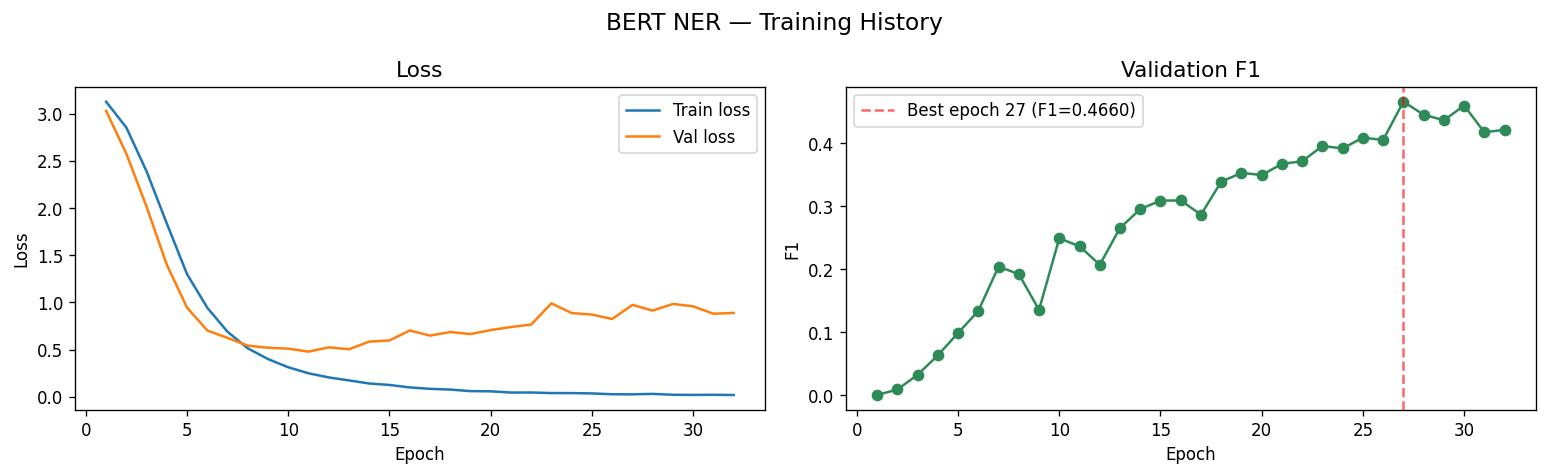

In [10]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1'], color='seagreen', marker='o')
best_ep = hist_df.loc[hist_df['val_f1'].idxmax()]
axes[1].axvline(best_ep['epoch'], linestyle='--', color='red', alpha=0.6,
                label=f"Best epoch {int(best_ep['epoch'])} (F1={best_ep['val_f1']:.4f})")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_title('Validation F1'); axes[1].legend()

plt.suptitle('BERT NER — Training History', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()

y_test_all, y_pred_all = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
        y_test_all.extend(yt)
        y_pred_all.extend(yp)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test_all, y_pred_all, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.2529    0.5366    0.3438        41
Companies worked at     0.2784    0.5506    0.3698        89
             Degree     0.4474    0.8718    0.5913        39
        Designation     0.3269    0.5231    0.4024        65
      Email Address     0.6389    0.9583    0.7667        24
    Graduation Year     0.2432    0.9000    0.3830        30
           Location     0.0408    0.4000    0.0741         5
               Name     0.8421    0.9412    0.8889        34
             Skills     0.0377    0.1111    0.0563        36
Years of Experience     0.3077    0.6667    0.4211         6

          micro avg     0.2902    0.6260    0.3966       369
          macro avg     0.3416    0.6459    0.4297       369
       weighted avg     0.3483    0.6260    0.4370       369



### Per-Entity Bar Chart

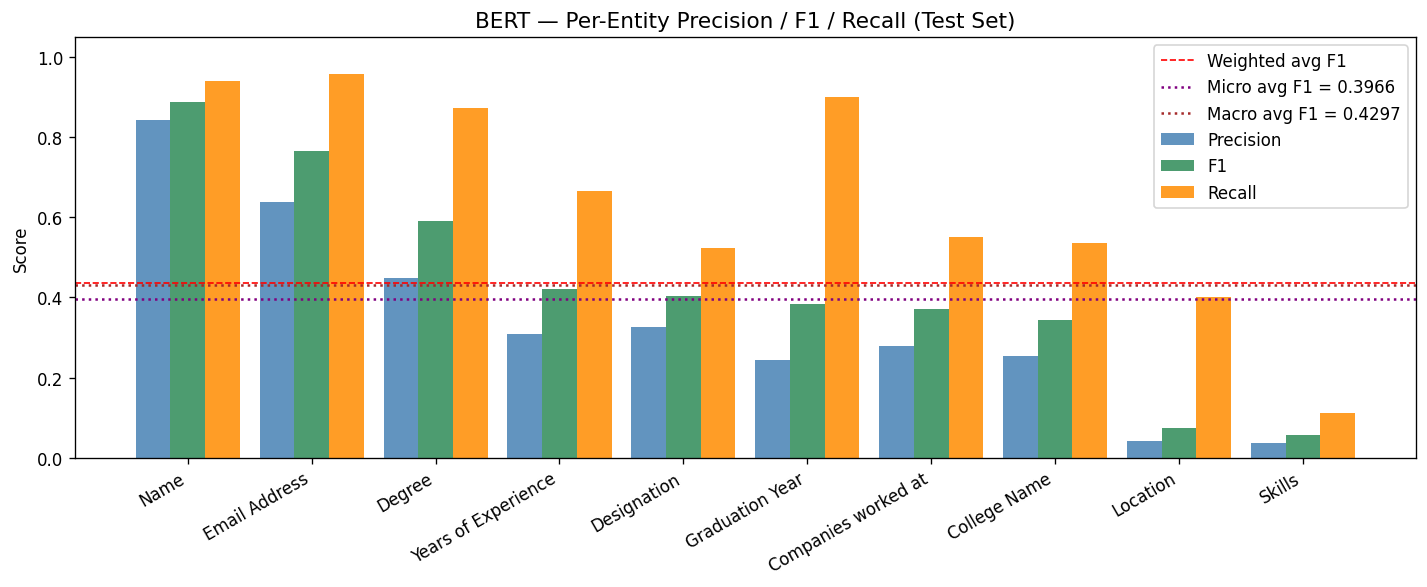

In [12]:
from seqeval.metrics import classification_report as seq_report

report_dict = seq_report(y_test_all, y_pred_all, digits=4, output_dict=True)

micro_f1 = report_dict['micro avg']['f1-score']
macro_f1 = report_dict['macro avg']['f1-score']

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores_    = [per_label[k]['f1-score'] for k in labels_sorted]
precision_    = [per_label[k]['precision'] for k in labels_sorted]
recall_       = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision_, width=w, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(list(x),            f1_scores_, width=w, label='F1',        color='seagreen',   alpha=0.85)
ax.bar([i + w for i in x], recall_,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('BERT — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0),
           color='red',    linestyle='--', linewidth=1,   label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':',  linewidth=1.5,
           label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':',  linewidth=1.5,
           label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [13]:
import re

def predict_resume(text: str) -> list:
    words = text.split()
    enc = tokenizer(
        words,
        is_split_into_words=True,
        max_length=MAX_LEN_BERT,
        truncation=True,
        stride=128,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors='pt',
    )

    all_results = {}
    for chunk_idx in range(len(enc['input_ids'])):
        chunk_input = {
            'input_ids'      : enc['input_ids'][chunk_idx].unsqueeze(0).to(DEVICE),
            'attention_mask' : enc['attention_mask'][chunk_idx].unsqueeze(0).to(DEVICE),
        }
        word_ids = enc.word_ids(chunk_idx)
        model.eval()
        with torch.no_grad():
            logits = model(**chunk_input).logits[0]
        pred_ids = logits.argmax(dim=-1).cpu().tolist()

        for wid, pid in zip(word_ids, pred_ids):
            if wid is None or wid in all_results:
                continue
            all_results[wid] = id2label[pid]  

    return [(words[wid], tag) for wid, tag in sorted(all_results.items())]


def extract_entities(predictions):
    """Group BIO-tagged tokens into entity strings by label."""
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


sample_tokens = subword_data[idx_test[0]]['tokens']
sample_text   = ' '.join(sample_tokens)
preds    = predict_resume(sample_text)
entities = extract_entities(preds)

print('Extracted Entities (Test Resume 0)')
for lbl, values in entities.items():
    print(f'[{lbl}]')
    for v in values:
        print(f'  • {v[:70]}')
    print()

Extracted Entities (Test Resume 0)
[Name]
  • dushyant bhatt

[Location]
  • hydera ##bad-deccan
  • hyderbad

[Email Address]
  • indeed ##com/r/dushyant bhatt/140749dace5dc26f

[Years of Experience]
  • 10+

[Designation]
  • software engineer

[Companies worked at]
  • microsoft
  • microsoft
  • microsoft
  • microsoft
  • microsoft
  • microsoft
  • microsoft
  • microsoft

[College Name]
  • saurashtra university



### Save Model & Results

In [14]:
# Save tokenizer + model config alongside weights
tokenizer.save_pretrained(model_save_dir / 'bert_ner')
model.config.save_pretrained(model_save_dir / 'bert_ner')

# Save results in the same schema as results_crf.pkl
results = {
    'model'          : 'BERT',
    'best_epoch'     : int(hist_df.loc[hist_df['val_f1'].idxmax(), 'epoch']),
    'val_f1'         : best_val_f1,
    'test_f1'        : f1_score(y_test_all, y_pred_all),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(y_test_all, y_pred_all),
    'test_recall'    : recall_score(y_test_all, y_pred_all),
    'y_test'         : y_test_all,
    'y_pred'         : y_pred_all,
    'idx_test'       : idx_test,
    'history'        : history,
}

with open(model_save_dir / 'results_bert.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Model  saved -> model_result/bert_best.pt')
print('Config saved -> model_result/bert_ner/')
print('Results saved -> model_result/results_bert.pkl')
print()
print('Final BERT Scores')
print(f"Val  F1       : {results['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Test Micro F1 : {results['test_f1_micro']:.4f}")
print(f"Test Macro F1 : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model  saved -> model_result/bert_best.pt
Config saved -> model_result/bert_ner/
Results saved -> model_result/results_bert.pkl

Final BERT Scores
Val  F1       : 0.4660
Test F1       : 0.3966
Test Micro F1 : 0.3966
Test Macro F1 : 0.4297
Test Precision: 0.2902
Test Recall   : 0.6260


In [15]:
# debug cell removed
